In [27]:
# Import all necessary files and create variables

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import pandas as pd
import os
from ipywidgets import interact
import seaborn as sns
import numpy as np
import ipywidgets as widgets

final_weather_data_folder = '../data'
bushfire_data_input_file = '../data/cleaned-bushfire-data.csv'


In [28]:
# Create a list of file names ending in '_weather_data.csv'
csv_files = [file for file in os.listdir(final_weather_data_folder) if file.endswith('_weather_data.csv')]
print(csv_files)


# Read all CSV files into DataFrames and store them in a list
dfs = [pd.read_csv(os.path.join(final_weather_data_folder, csv_file)) for csv_file in csv_files]

weather_df = pd.concat(dfs, ignore_index=True)

['2001_weather_data.csv', '2002_weather_data.csv', '2003_weather_data.csv', '2004_weather_data.csv', '2005_weather_data.csv', '2006_weather_data.csv', '2007_weather_data.csv', '2008_weather_data.csv', '2009_weather_data.csv', '2011_weather_data.csv', '2012_weather_data.csv', '2013_weather_data.csv', '2014_weather_data.csv', '2015_weather_data.csv', '2016_weather_data.csv', '2018_weather_data.csv', '2019_weather_data.csv', '2020_weather_data.csv', '2022_weather_data.csv', '2023_weather_data.csv', '2024_weather_data.csv']


In [29]:
# Convert temperature columns to numeric
weather_df['TMAX (°C)'] = pd.to_numeric(weather_df['TMAX (°C)'], errors='coerce')
weather_df['TMIN (°C)'] = pd.to_numeric(weather_df['TMIN (°C)'], errors='coerce')

# Calculate average temperature
weather_df['AvgTemp'] = (weather_df['TMAX (°C)'] + weather_df['TMIN (°C)']) / 2

# Group by state and calculate average temperature
avg_temp_per_state = weather_df.groupby('STATE')['AvgTemp'].mean().reset_index()

# Process DATE column
weather_df['Date'] = pd.to_datetime(weather_df['Date'], errors='coerce')

# Drop rows with missing values
weather_df_cleaned = weather_df.dropna(subset=['TMAX (°C)', 'TMIN (°C)', 'Date', 'STATE'])

# Remove invalid rows using query
weather_df_cleaned = weather_df_cleaned.query('`TMAX (°C)` >= `TMIN (°C)` and `TMAX (°C)` <= 56.7 and `TMAX (°C)` >= -90')

# Remove duplicates
weather_df_cleaned = weather_df_cleaned.drop_duplicates()

# Log removed rows
print(f"Removed {len(weather_df) - len(weather_df_cleaned)} rows during cleaning")

# Update weather_df to cleaned data
weather_df = weather_df_cleaned

# Display the cleaned DataFrame
print(weather_df)

Removed 154671 rows during cleaning
          ELEVATION  LATITUDE  LONGITUDE       Date  TMAX (°C)  TMIN (°C)  \
0             275.8   44.8322   -93.4706 2001-01-01       -8.9      -21.1   
1             439.2   46.8997   -95.0669 2001-01-01      -12.8      -32.8   
2             400.5   43.4008   -94.7478 2001-01-01      -11.1      -18.9   
3             368.8   46.0303   -91.4425 2001-01-01       -8.3      -26.7   
4             312.1   41.7631   -96.1797 2001-01-01      -10.6      -20.6   
...             ...       ...        ...        ...        ...        ...   
59558025      757.7   67.5733  -158.4317 2024-09-18        2.3        1.3   
59558026      251.5   66.0933  -152.1700 2024-09-18        5.6        0.6   
59558027       71.6   67.1386  -159.0436 2024-09-18        7.8        4.4   
59558028      125.6   67.9333  -162.3000 2024-09-18        5.0        1.1   
59558029      121.9   60.5917  -150.3167 2024-09-18        8.9        6.1   

         STATE  AvgTemp  
0           M

In [30]:
# Load the bushfire data
bushfire_data = pd.read_csv(bushfire_data_input_file)

C:\Users\User\AppData\Local\Temp\ipykernel_8588\2006761352.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


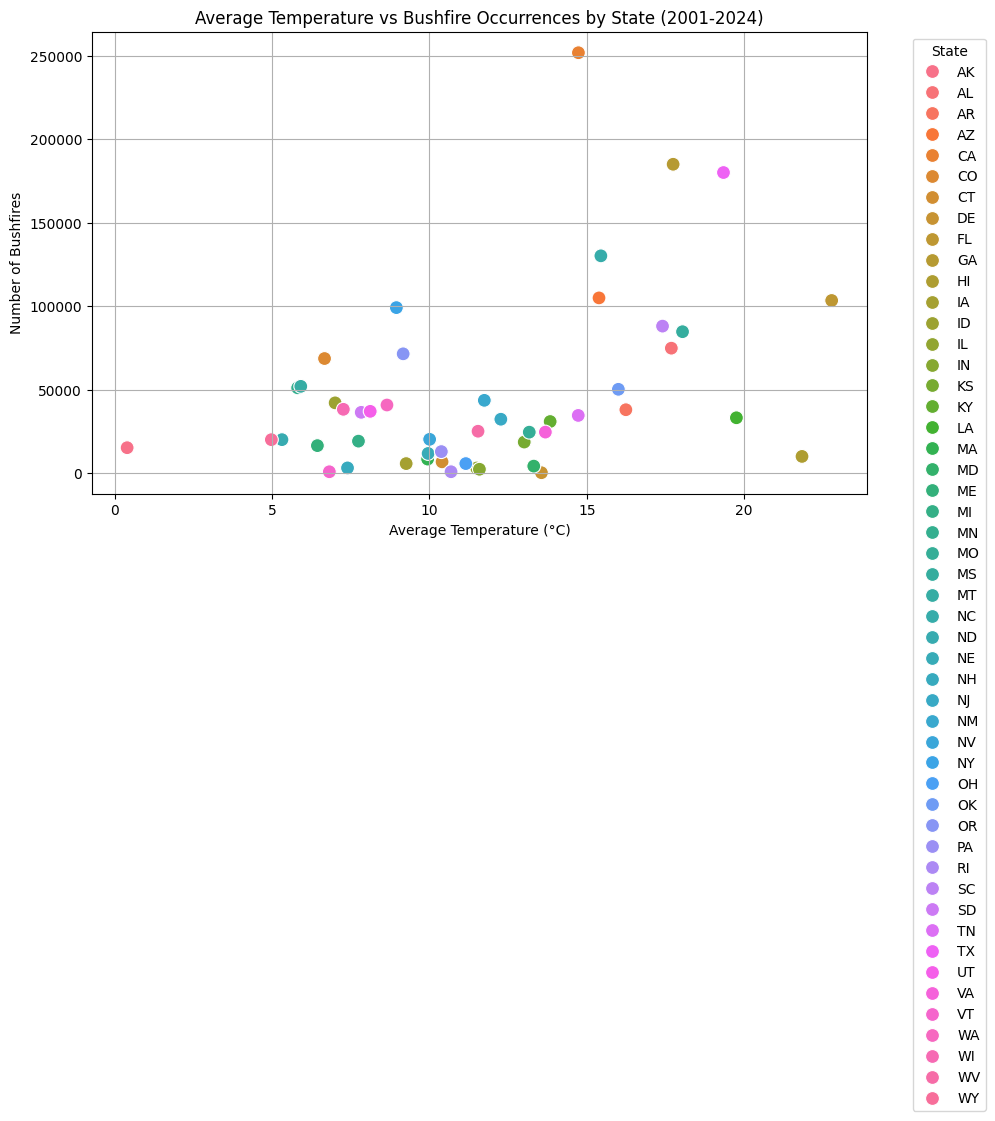

In [31]:
# Count occurrences of bushfires by state
bushfire_counts = bushfire_data['state'].value_counts().reset_index()
bushfire_counts.columns = ['STATE', 'BushfireCount']

# Merge average temperature and bushfire counts on state
merged_data = pd.merge(avg_temp_per_state, bushfire_counts, on='STATE')

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='AvgTemp', y='BushfireCount', hue='STATE', s=100)
plt.title('Average Temperature vs Bushfire Occurrences by State (2001-2024)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Number of Bushfires')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

In [33]:
# Function to plot bushfire occurrences
def plot_bushfire_occurrences(selected_state, selected_year):
    plt.figure(figsize=(12, 6))
    
    # Filter data based on selected state and year
    filtered_data = bushfire_counts[(bushfire_counts['state'] == selected_state) & 
                                     (bushfire_counts['Year'] == selected_year)]
    
    # Check if there's data to plot
    if not filtered_data.empty:
        plt.plot(filtered_data['DOY'], filtered_data['BushfireCount'], marker='o')
        plt.title(f'Bushfire Occurrences in {selected_state} for Year {selected_year}')
        plt.xlabel('Day of Year (DOY)')
        plt.ylabel('Number of Bushfires')
        plt.xticks(rotation=45)
    else:
        plt.title(f'No data available for {selected_state} in {selected_year}')
    
    plt.grid()
    plt.tight_layout()
    plt.show()

# Create dropdowns for state and year selection
state_dropdown = widgets.Dropdown(
    options=bushfire_counts['state'].unique(),
    description='Select State:',
    value=bushfire_counts['state'].unique()[0]  # Default value
)

year_dropdown = widgets.Dropdown(
    options=bushfire_counts['Year'].unique(),
    description='Select Year:',
    value=bushfire_counts['Year'].unique()[0]  # Default value
)

# Create the interactive plot
interact(plot_bushfire_occurrences, selected_state=state_dropdown, selected_year=year_dropdown)

NameError: name 'widgets' is not defined

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given